# Named Entity Recognition ABSA

Notebook ini digunakan untuk membangun model Named Entity Recognition ABSA. Dataset berasal dari hasil split NER yang telah dibuat dari file anotasi Prodigy. Model yang digunakan adalah BiLSTM untuk token classification dengan tag BIO.

import json
import numpy as np
import pandas as pd
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report

In [67]:
import json
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [68]:
print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU tersedia: []


In [69]:
DATA_PATH = "../dataset/Kelp4_dataset_anotasi.jsonl"

DATASET_DIR = "../dataset"
MODEL_DIR = "../models"

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Dataset path:", DATA_PATH)
print("Model dir:", MODEL_DIR)

Dataset path: ../dataset/Kelp4_dataset_anotasi.jsonl
Model dir: ../models


In [70]:
data = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

print("Jumlah data awal:", len(data))

Jumlah data awal: 2118


In [71]:
df = pd.DataFrame(data)

print("Kolom dataset:")
print(df.columns.tolist())

df.head()

Kolom dataset:
['text', 'tokens', 'spans', '_input_hash', '_task_hash', 'options', '_view_id', 'accept', 'config', 'answer', '_timestamp', '_annotator_id', '_session_id']


,text,tokens,spans,_input_hash,_task_hash,options,_view_id,accept,config,answer,_timestamp,_annotator_id,_session_id
0,Semuanya worth bakso mozanya enak banget,"[{'text': 'Semuanya', 'start': 0, 'end': 8, 'i...","[{'start': 0, 'end': 40, 'token_start': 0, 'to...",-832848900,-485476066,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[PRODUCT_POSITIVE],{'choice_style': 'multiple'},accept,1776436180,nlp4_genap2526-230712427,nlp4_genap2526-230712427
1,Bakso bakar ya enak dan pas,"[{'text': 'Bakso', 'start': 0, 'end': 5, 'id':...","[{'start': 0, 'end': 27, 'token_start': 0, 'to...",616756199,-494867163,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[PRODUCT_POSITIVE],{'choice_style': 'multiple'},accept,1776436292,nlp4_genap2526-230712427,nlp4_genap2526-230712427
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[{'text': 'Saya', 'start': 0, 'end': 4, 'id': ...","[{'start': 41, 'end': 75, 'token_start': 8, 't...",-1099850682,-1708591340,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,"[PRODUCT_NEGATIVE, OUT_OF_TOPIC, PLACE_NEGATIVE]",{'choice_style': 'multiple'},accept,1776436302,nlp4_genap2526-230712427,nlp4_genap2526-230712427
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[{'text': 'Ud', 'start': 0, 'end': 2, 'id': 0,...","[{'start': 0, 'end': 23, 'token_start': 0, 'to...",1518700474,1889327892,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,"[OUT_OF_TOPIC, PLACE_NEGATIVE, PRODUCT_POSITIVE]",{'choice_style': 'multiple'},accept,1776436337,nlp4_genap2526-230712427,nlp4_genap2526-230712427
4,"servisnya oke banget. baru dateng, mba pelayan...","[{'text': 'servisnya', 'start': 0, 'end': 9, '...","[{'start': 0, 'end': 20, 'token_start': 0, 'to...",1104821067,-1778492930,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[OUT_OF_TOPIC],{'choice_style': 'multiple'},accept,1776436409,nlp4_genap2526-230712427,nlp4_genap2526-230712427


In [72]:
required_columns = ["text", "accept", "spans", "tokens", "answer"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) == 0:
    print("Semua kolom wajib tersedia.")
else:
    print("Kolom yang hilang:", missing_columns)

Semua kolom wajib tersedia.


In [73]:
df_main = df[["text", "accept", "spans", "tokens", "answer"]].copy()

print("Shape df_main:", df_main.shape)
df_main.head()

Shape df_main: (2118, 5)


,text,accept,spans,tokens,answer
0,Semuanya worth bakso mozanya enak banget,[PRODUCT_POSITIVE],"[{'start': 0, 'end': 40, 'token_start': 0, 'to...","[{'text': 'Semuanya', 'start': 0, 'end': 8, 'i...",accept
1,Bakso bakar ya enak dan pas,[PRODUCT_POSITIVE],"[{'start': 0, 'end': 27, 'token_start': 0, 'to...","[{'text': 'Bakso', 'start': 0, 'end': 5, 'id':...",accept
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[PRODUCT_NEGATIVE, OUT_OF_TOPIC, PLACE_NEGATIVE]","[{'start': 41, 'end': 75, 'token_start': 8, 't...","[{'text': 'Saya', 'start': 0, 'end': 4, 'id': ...",accept
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[OUT_OF_TOPIC, PLACE_NEGATIVE, PRODUCT_POSITIVE]","[{'start': 0, 'end': 23, 'token_start': 0, 'to...","[{'text': 'Ud', 'start': 0, 'end': 2, 'id': 0,...",accept
4,"servisnya oke banget. baru dateng, mba pelayan...",[OUT_OF_TOPIC],"[{'start': 0, 'end': 20, 'token_start': 0, 'to...","[{'text': 'servisnya', 'start': 0, 'end': 9, '...",accept


In [74]:
df_main = df_main[df_main["answer"] == "accept"].copy()
df_main = df_main.reset_index(drop=True)

print("Jumlah data dengan answer accept:", len(df_main))
df_main.head()

Jumlah data dengan answer accept: 2117


,text,accept,spans,tokens,answer
0,Semuanya worth bakso mozanya enak banget,[PRODUCT_POSITIVE],"[{'start': 0, 'end': 40, 'token_start': 0, 'to...","[{'text': 'Semuanya', 'start': 0, 'end': 8, 'i...",accept
1,Bakso bakar ya enak dan pas,[PRODUCT_POSITIVE],"[{'start': 0, 'end': 27, 'token_start': 0, 'to...","[{'text': 'Bakso', 'start': 0, 'end': 5, 'id':...",accept
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[PRODUCT_NEGATIVE, OUT_OF_TOPIC, PLACE_NEGATIVE]","[{'start': 41, 'end': 75, 'token_start': 8, 't...","[{'text': 'Saya', 'start': 0, 'end': 4, 'id': ...",accept
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[OUT_OF_TOPIC, PLACE_NEGATIVE, PRODUCT_POSITIVE]","[{'start': 0, 'end': 23, 'token_start': 0, 'to...","[{'text': 'Ud', 'start': 0, 'end': 2, 'id': 0,...",accept
4,"servisnya oke banget. baru dateng, mba pelayan...",[OUT_OF_TOPIC],"[{'start': 0, 'end': 20, 'token_start': 0, 'to...","[{'text': 'servisnya', 'start': 0, 'end': 9, '...",accept


In [75]:
df_main["jumlah_label"] = df_main["accept"].apply(lambda x: len(x))

invalid_no_label = df_main[df_main["jumlah_label"] == 0].copy()

print("Jumlah data tanpa label:", len(invalid_no_label))

df_main = df_main[df_main["jumlah_label"] > 0].copy()
df_main = df_main.reset_index(drop=True)

print("Jumlah data setelah hapus tanpa label:", len(df_main))

Jumlah data tanpa label: 14
Jumlah data setelah hapus tanpa label: 2103


In [76]:
sample_idx = 0

print("Contoh review:")
print(df_main.loc[sample_idx, "text"])

print("\nContoh tokens:")
print(df_main.loc[sample_idx, "tokens"][:10])

print("\nContoh spans:")
print(df_main.loc[sample_idx, "spans"])

Contoh review:
Semuanya worth bakso mozanya enak banget

Contoh tokens:
[{'text': 'Semuanya', 'start': 0, 'end': 8, 'id': 0, 'ws': True}, {'text': 'worth', 'start': 9, 'end': 14, 'id': 1, 'ws': True}, {'text': 'bakso', 'start': 15, 'end': 20, 'id': 2, 'ws': True}, {'text': 'mozanya', 'start': 21, 'end': 28, 'id': 3, 'ws': True}, {'text': 'enak', 'start': 29, 'end': 33, 'id': 4, 'ws': True}, {'text': 'banget', 'start': 34, 'end': 40, 'id': 5, 'ws': False}]

Contoh spans:
[{'start': 0, 'end': 40, 'token_start': 0, 'token_end': 5, 'label': 'PRODUCT_POSITIVE'}]


In [77]:
def validate_spans_and_tokens(row):
    tokens = row["tokens"]
    spans = row["spans"]
    
    if not isinstance(tokens, list):
        return False
    
    if not isinstance(spans, list):
        return False
    
    token_len = len(tokens)
    
    for span in spans:
        if "token_start" not in span or "token_end" not in span:
            return False
        
        token_start = span["token_start"]
        token_end = span["token_end"]
        
        if token_start < 0 or token_end < 0:
            return False
        
        if token_start >= token_len or token_end >= token_len:
            return False
        
        if token_start > token_end:
            return False
    
    return True


df_main["span_token_valid"] = df_main.apply(validate_spans_and_tokens, axis=1)

print("Distribusi validasi span-token:")
print(df_main["span_token_valid"].value_counts())

Distribusi validasi span-token:
span_token_valid
True    2103
Name: count, dtype: int64


### Ambil Data Span Valid

In [78]:
df_main = df_main[df_main["span_token_valid"] == True].copy()
df_main = df_main.reset_index(drop=True)

print("Jumlah data NER valid:", len(df_main))

Jumlah data NER valid: 2103


In [79]:
def map_span_label_to_aspect(label):
    if label.startswith("PRODUCT"):
        return "PRODUCT"
    elif label.startswith("PRICE"):
        return "PRICE"
    elif label.startswith("PLACE"):
        return "PLACE"
    elif label.startswith("PROMOTION"):
        return "PROMOTION"
    else:
        return None

In [80]:
def convert_to_bio(tokens, spans):
    token_texts = [token["text"] for token in tokens]
    bio_tags = ["O"] * len(tokens)
    
    for span in spans:
        aspect = map_span_label_to_aspect(span["label"])
        
        if aspect is None:
            continue
        
        token_start = span["token_start"]
        token_end = span["token_end"]
        
        if token_start < 0 or token_end >= len(tokens):
            continue
        
        for i in range(token_start, token_end + 1):
            if i == token_start:
                bio_tags[i] = f"B-{aspect}"
            else:
                bio_tags[i] = f"I-{aspect}"
    
    return token_texts, bio_tags

In [81]:
ner_data = []

for idx, row in df_main.iterrows():
    tokens = row["tokens"]
    spans = row["spans"]
    
    token_texts, bio_tags = convert_to_bio(tokens, spans)
    
    ner_data.append({
        "text": row["text"],
        "tokens": token_texts,
        "ner_tags": bio_tags,
        "spans": spans
    })

df_ner = pd.DataFrame(ner_data)

print("Shape df_ner:", df_ner.shape)
df_ner.head()

Shape df_ner: (2103, 4)


,text,tokens,ner_tags,spans
0,Semuanya worth bakso mozanya enak banget,"[Semuanya, worth, bakso, mozanya, enak, banget]","[B-PRODUCT, I-PRODUCT, I-PRODUCT, I-PRODUCT, I...","[{'start': 0, 'end': 40, 'token_start': 0, 'to..."
1,Bakso bakar ya enak dan pas,"[Bakso, bakar, ya, enak, dan, pas]","[B-PRODUCT, I-PRODUCT, I-PRODUCT, I-PRODUCT, I...","[{'start': 0, 'end': 27, 'token_start': 0, 'to..."
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[Saya, kesini, jam, 3, sore, bersama, keluarga...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[{'start': 41, 'end': 75, 'token_start': 8, 't..."
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[Ud, 3x, ksni, tiap, k, jogja, ,, baksonya, en...","[O, O, O, O, O, O, O, B-PRODUCT, I-PRODUCT, I-...","[{'start': 0, 'end': 23, 'token_start': 0, 'to..."
4,"servisnya oke banget. baru dateng, mba pelayan...","[servisnya, oke, banget, ., baru, dateng, ,, m...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]","[{'start': 0, 'end': 20, 'token_start': 0, 'to..."


In [82]:
df_ner["token_len"] = df_ner["tokens"].apply(len)
df_ner["tag_len"] = df_ner["ner_tags"].apply(len)
df_ner["length_valid"] = df_ner["token_len"] == df_ner["tag_len"]

print("Distribusi validasi panjang token-tag:")
print(df_ner["length_valid"].value_counts())

df_ner[df_ner["length_valid"] == False].head()

Distribusi validasi panjang token-tag:
length_valid
True    2103
Name: count, dtype: int64


,text,tokens,ner_tags,spans,token_len,tag_len,length_valid


In [83]:
df_ner = df_ner[df_ner["length_valid"] == True].copy()
df_ner = df_ner.reset_index(drop=True)

print("Jumlah data NER final:", len(df_ner))

Jumlah data NER final: 2103


In [84]:
sample_idx = 0

pd.DataFrame({
    "token": df_ner.loc[sample_idx, "tokens"],
    "tag": df_ner.loc[sample_idx, "ner_tags"]
}).head(30)

,token,tag
0,Semuanya,B-PRODUCT
1,worth,I-PRODUCT
2,bakso,I-PRODUCT
3,mozanya,I-PRODUCT
4,enak,I-PRODUCT
5,banget,I-PRODUCT


# EDA NER

In [85]:
df_ner["jumlah_token"] = df_ner["tokens"].apply(len)

df_ner["jumlah_token"].describe()

count    2103.000000
mean       27.021398
std        34.683248
min         5.000000
25%         9.000000
50%        15.000000
75%        30.000000
max       318.000000
Name: jumlah_token, dtype: float64

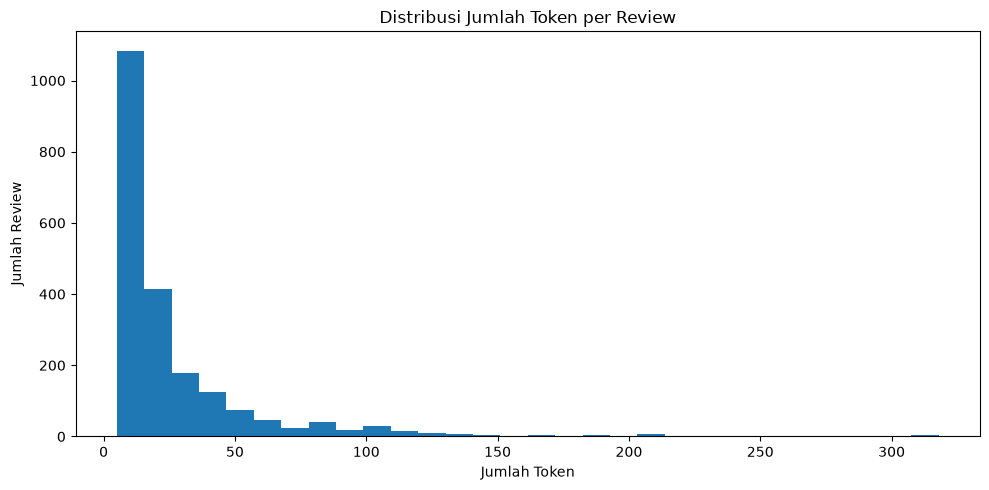

In [86]:
plt.figure(figsize=(10, 5))
plt.hist(df_ner["jumlah_token"], bins=30)
plt.xlabel("Jumlah Token")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Jumlah Token per Review")
plt.tight_layout()
plt.show()

In [87]:
all_tags = []

for tags in df_ner["ner_tags"]:
    all_tags.extend(tags)

tag_distribution = Counter(all_tags)

tag_distribution_df = pd.DataFrame(
    tag_distribution.items(),
    columns=["tag", "jumlah"]
).sort_values(by="jumlah", ascending=False).reset_index(drop=True)

tag_distribution_df

,tag,jumlah
0,I-PRODUCT,19958
1,O,18816
2,I-PLACE,6937
3,I-PROMOTION,5050
4,B-PRODUCT,2849
5,I-PRICE,1411
6,B-PLACE,941
7,B-PROMOTION,603
8,B-PRICE,261


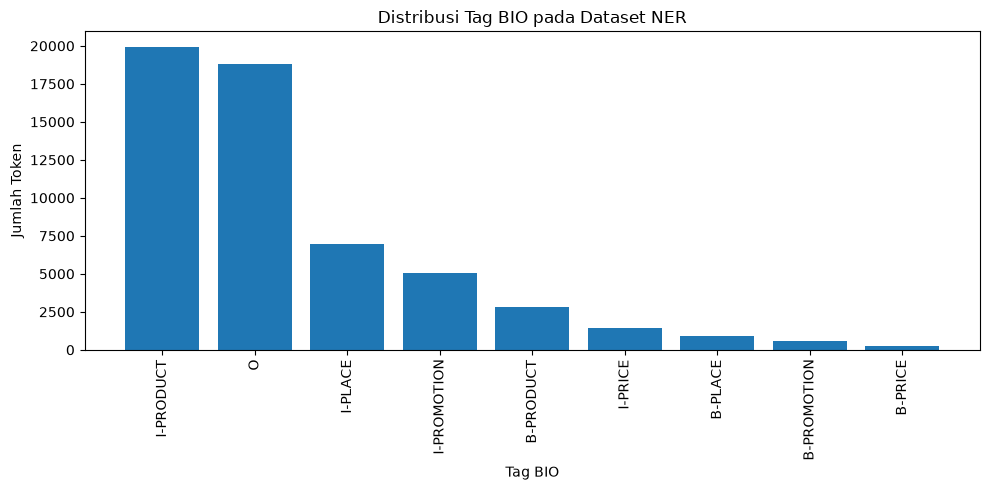

In [88]:
plt.figure(figsize=(10, 5))
plt.bar(tag_distribution_df["tag"], tag_distribution_df["jumlah"])
plt.xticks(rotation=90)
plt.xlabel("Tag BIO")
plt.ylabel("Jumlah Token")
plt.title("Distribusi Tag BIO pada Dataset NER")
plt.tight_layout()
plt.show()

In [89]:
def get_entity_from_span_label(label):
    aspect = map_span_label_to_aspect(label)
    return aspect if aspect is not None else "UNKNOWN"


entity_counter = Counter()

for spans in df_ner["spans"]:
    for span in spans:
        entity = get_entity_from_span_label(span["label"])
        entity_counter[entity] += 1

entity_distribution_df = pd.DataFrame(
    entity_counter.items(),
    columns=["entity", "jumlah_span"]
).sort_values(by="jumlah_span", ascending=False).reset_index(drop=True)

entity_distribution_df

,entity,jumlah_span
0,PRODUCT,2849
1,UNKNOWN,1060
2,PLACE,941
3,PROMOTION,603
4,PRICE,261


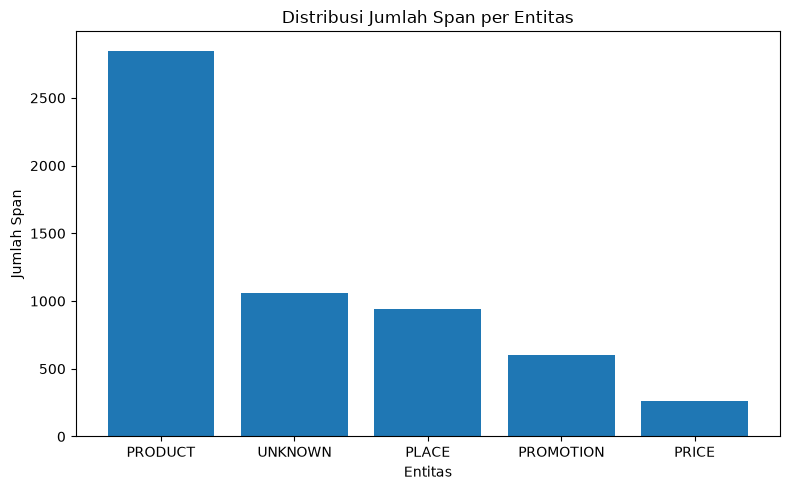

In [90]:
plt.figure(figsize=(8, 5))
plt.bar(entity_distribution_df["entity"], entity_distribution_df["jumlah_span"])
plt.xlabel("Entitas")
plt.ylabel("Jumlah Span")
plt.title("Distribusi Jumlah Span per Entitas")
plt.tight_layout()
plt.show()

In [91]:
df_ner["jumlah_entitas"] = df_ner["spans"].apply(len)

df_ner["jumlah_entitas"].describe()

count    2103.000000
mean        2.717071
std         2.194476
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        28.000000
Name: jumlah_entitas, dtype: float64

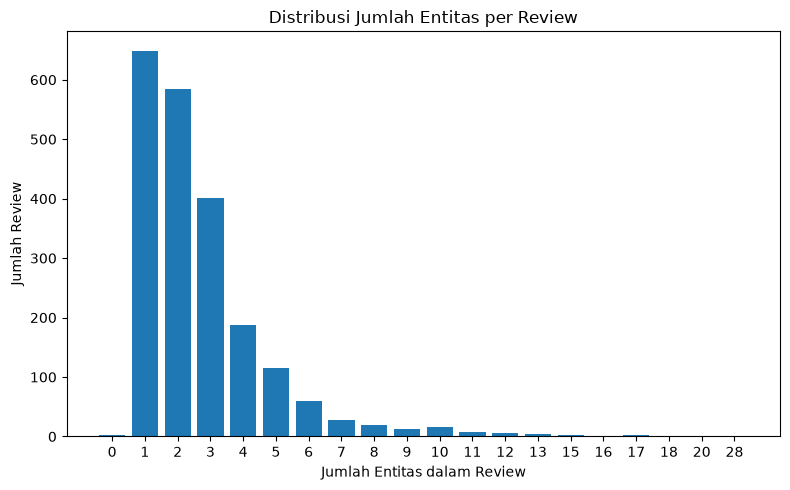

jumlah_entitas
0       3
1     649
2     584
3     401
4     188
5     116
6      59
7      28
8      19
9      12
10     16
11      7
12      6
13      5
15      3
16      1
17      3
18      1
20      1
28      1
Name: count, dtype: int64

In [92]:
entity_per_review_distribution = df_ner["jumlah_entitas"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    entity_per_review_distribution.index.astype(str),
    entity_per_review_distribution.values
)
plt.xlabel("Jumlah Entitas dalam Review")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Jumlah Entitas per Review")
plt.tight_layout()
plt.show()

entity_per_review_distribution

In [93]:
span_length_rows = []

for spans in df_ner["spans"]:
    for span in spans:
        entity = get_entity_from_span_label(span["label"])
        token_start = span["token_start"]
        token_end = span["token_end"]
        span_length = token_end - token_start + 1
        
        span_length_rows.append({
            "entity": entity,
            "span_length": span_length
        })

span_length_df = pd.DataFrame(span_length_rows)

span_length_summary = span_length_df.groupby("entity")["span_length"].agg(
    ["count", "mean", "min", "max"]
).reset_index()

span_length_summary

,entity,count,mean,min,max
0,PLACE,941,8.371945,1,111
1,PRICE,261,6.406130,1,51
2,PRODUCT,2849,8.005265,1,146
3,PROMOTION,603,9.374793,1,57
4,UNKNOWN,1060,12.883962,1,149


# Split Dataset NER

In [94]:
df_ner_final = df_ner[["text", "tokens", "ner_tags", "spans"]].copy()

print("Shape df_ner_final:", df_ner_final.shape)
df_ner_final.head()

Shape df_ner_final: (2103, 4)


,text,tokens,ner_tags,spans
0,Semuanya worth bakso mozanya enak banget,"[Semuanya, worth, bakso, mozanya, enak, banget]","[B-PRODUCT, I-PRODUCT, I-PRODUCT, I-PRODUCT, I...","[{'start': 0, 'end': 40, 'token_start': 0, 'to..."
1,Bakso bakar ya enak dan pas,"[Bakso, bakar, ya, enak, dan, pas]","[B-PRODUCT, I-PRODUCT, I-PRODUCT, I-PRODUCT, I...","[{'start': 0, 'end': 27, 'token_start': 0, 'to..."
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[Saya, kesini, jam, 3, sore, bersama, keluarga...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[{'start': 41, 'end': 75, 'token_start': 8, 't..."
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[Ud, 3x, ksni, tiap, k, jogja, ,, baksonya, en...","[O, O, O, O, O, O, O, B-PRODUCT, I-PRODUCT, I-...","[{'start': 0, 'end': 23, 'token_start': 0, 'to..."
4,"servisnya oke banget. baru dateng, mba pelayan...","[servisnya, oke, banget, ., baru, dateng, ,, m...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]","[{'start': 0, 'end': 20, 'token_start': 0, 'to..."


In [95]:
ner_train_df, ner_temp_df = train_test_split(
    df_ner_final,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

ner_val_df, ner_test_df = train_test_split(
    ner_temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

ner_train_df = ner_train_df.reset_index(drop=True)
ner_val_df = ner_val_df.reset_index(drop=True)
ner_test_df = ner_test_df.reset_index(drop=True)

print("NER Train:", ner_train_df.shape)
print("NER Validation:", ner_val_df.shape)
print("NER Test:", ner_test_df.shape)

NER Train: (1682, 4)
NER Validation: (210, 4)
NER Test: (211, 4)


In [96]:
def count_tags_from_df(df_split):
    tag_counter = Counter()
    
    for tags in df_split["ner_tags"]:
        tag_counter.update(tags)
    
    return tag_counter


train_tag_counter = count_tags_from_df(ner_train_df)
val_tag_counter = count_tags_from_df(ner_val_df)
test_tag_counter = count_tags_from_df(ner_test_df)

all_tag_names = sorted(list(set(
    list(train_tag_counter.keys()) +
    list(val_tag_counter.keys()) +
    list(test_tag_counter.keys())
)))

split_tag_distribution = pd.DataFrame({
    "tag": all_tag_names,
    "train": [train_tag_counter.get(tag, 0) for tag in all_tag_names],
    "validation": [val_tag_counter.get(tag, 0) for tag in all_tag_names],
    "test": [test_tag_counter.get(tag, 0) for tag in all_tag_names]
})

split_tag_distribution

,tag,train,validation,test
0,B-PLACE,761,92,88
1,B-PRICE,206,27,28
2,B-PRODUCT,2238,281,330
3,B-PROMOTION,490,59,54
4,I-PLACE,5748,582,607
5,I-PRICE,1130,148,133
6,I-PRODUCT,15925,1878,2155
7,I-PROMOTION,4101,526,423
8,O,15285,1570,1961


In [97]:
def save_ner_jsonl(df_split, path):
    with open(path, "w", encoding="utf-8") as f:
        for _, row in df_split.iterrows():
            item = {
                "text": row["text"],
                "tokens": row["tokens"],
                "ner_tags": row["ner_tags"],
                "spans": row["spans"]
            }
            f.write(json.dumps(item, ensure_ascii=False) + "\n")

In [98]:
save_ner_jsonl(ner_train_df, "../dataset/Kelp4_ner_train.jsonl")
save_ner_jsonl(ner_val_df, "../dataset/Kelp4_ner_val.jsonl")
save_ner_jsonl(ner_test_df, "../dataset/Kelp4_ner_test.jsonl")

print("Split dataset NER berhasil disimpan.")

Split dataset NER berhasil disimpan.


# Feature Engineering NER

In [99]:
X_train_tokens = ner_train_df["tokens"].tolist()
y_train_tags = ner_train_df["ner_tags"].tolist()

X_val_tokens = ner_val_df["tokens"].tolist()
y_val_tags = ner_val_df["ner_tags"].tolist()

X_test_tokens = ner_test_df["tokens"].tolist()
y_test_tags = ner_test_df["ner_tags"].tolist()

print("Jumlah train:", len(X_train_tokens))
print("Jumlah validation:", len(X_val_tokens))
print("Jumlah test:", len(X_test_tokens))

Jumlah train: 1682
Jumlah validation: 210
Jumlah test: 211


In [100]:
word_counter = Counter()

for tokens in X_train_tokens:
    word_counter.update(tokens)

word2idx = {
    "PAD": 0,
    "UNK": 1
}

for word, count in word_counter.items():
    if word not in word2idx:
        word2idx[word] = len(word2idx)

idx2word = {
    idx: word
    for word, idx in word2idx.items()
}

print("Jumlah vocabulary:", len(word2idx))

Jumlah vocabulary: 4742


In [101]:
tag_counter = Counter()

for tags in y_train_tags:
    tag_counter.update(tags)

tag_list = sorted(list(tag_counter.keys()))

tag2idx = {
    tag: idx
    for idx, tag in enumerate(tag_list)
}

idx2tag = {
    idx: tag
    for tag, idx in tag2idx.items()
}

print("Tag list:")
print(tag_list)

print("\nTag2idx:")
print(tag2idx)

Tag list:
['B-PLACE', 'B-PRICE', 'B-PRODUCT', 'B-PROMOTION', 'I-PLACE', 'I-PRICE', 'I-PRODUCT', 'I-PROMOTION', 'O']

Tag2idx:
{'B-PLACE': 0, 'B-PRICE': 1, 'B-PRODUCT': 2, 'B-PROMOTION': 3, 'I-PLACE': 4, 'I-PRICE': 5, 'I-PRODUCT': 6, 'I-PROMOTION': 7, 'O': 8}


In [102]:
MAX_LEN = 80

print("MAX_LEN:", MAX_LEN)

MAX_LEN: 80


In [103]:
def encode_tokens(token_sequences, word2idx, max_len):
    encoded = []
    
    for tokens in token_sequences:
        seq = [
            word2idx.get(token, word2idx["UNK"])
            for token in tokens
        ]
        encoded.append(seq)
    
    padded = pad_sequences(
        encoded,
        maxlen=max_len,
        padding="post",
        truncating="post",
        value=word2idx["PAD"]
    )
    
    return padded


def encode_tags(tag_sequences, tag2idx, max_len):
    encoded = []
    o_tag_idx = tag2idx["O"]
    
    for tags in tag_sequences:
        seq = [
            tag2idx[tag]
            for tag in tags
        ]
        encoded.append(seq)
    
    padded = pad_sequences(
        encoded,
        maxlen=max_len,
        padding="post",
        truncating="post",
        value=o_tag_idx
    )
    
    return padded

In [104]:
X_train_ner = encode_tokens(X_train_tokens, word2idx, MAX_LEN)
X_val_ner = encode_tokens(X_val_tokens, word2idx, MAX_LEN)
X_test_ner = encode_tokens(X_test_tokens, word2idx, MAX_LEN)

y_train_ner = encode_tags(y_train_tags, tag2idx, MAX_LEN)
y_val_ner = encode_tags(y_val_tags, tag2idx, MAX_LEN)
y_test_ner = encode_tags(y_test_tags, tag2idx, MAX_LEN)

print("X_train_ner:", X_train_ner.shape)
print("y_train_ner:", y_train_ner.shape)
print("X_val_ner:", X_val_ner.shape)
print("y_val_ner:", y_val_ner.shape)
print("X_test_ner:", X_test_ner.shape)
print("y_test_ner:", y_test_ner.shape)

X_train_ner: (1682, 80)
y_train_ner: (1682, 80)
X_val_ner: (210, 80)
y_val_ner: (210, 80)
X_test_ner: (211, 80)
y_test_ner: (211, 80)


In [105]:
from IPython.display import Markdown

Markdown("""
### Strategi Penanganan Imbalance pada NER

Dataset NER memiliki distribusi tag yang tidak seimbang. Tag `O` dan tag terkait `PRODUCT` lebih dominan dibandingkan tag `PRICE` dan `PROMOTION`.

Strategi yang digunakan:
1. Menampilkan distribusi tag BIO untuk mengetahui imbalance.
2. Menggunakan validation set dan early stopping agar model tidak overfitting pada label dominan.
3. Mengabaikan token PAD saat evaluasi sehingga metrik tidak bias oleh padding.
4. Melakukan analisis kesalahan token-level untuk melihat label yang sering salah.
5. Menyimpan prediksi token ke dataframe untuk analisis error.
""")


### Strategi Penanganan Imbalance pada NER

Dataset NER memiliki distribusi tag yang tidak seimbang. Tag `O` dan tag terkait `PRODUCT` lebih dominan dibandingkan tag `PRICE` dan `PROMOTION`.

Strategi yang digunakan:
1. Menampilkan distribusi tag BIO untuk mengetahui imbalance.
2. Menggunakan validation set dan early stopping agar model tidak overfitting pada label dominan.
3. Mengabaikan token PAD saat evaluasi sehingga metrik tidak bias oleh padding.
4. Melakukan analisis kesalahan token-level untuk melihat label yang sering salah.
5. Menyimpan prediksi token ke dataframe untuk analisis error.


# Model Training NER
## Bangun Model BiLSTM

In [106]:
VOCAB_SIZE = len(word2idx)
NUM_TAGS = len(tag2idx)

model_ner = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),
    Bidirectional(
        LSTM(
            units=64,
            return_sequences=True
        )
    ),
    Dropout(0.3),
    TimeDistributed(
        Dense(
            NUM_TAGS,
            activation="softmax"
        )
    )
])

model_ner.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_ner.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [107]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_ner = model_ner.fit(
    X_train_ner,
    y_train_ner,
    validation_data=(X_val_ner, y_val_ner),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4150 - loss: 1.7314 - val_accuracy: 0.5017 - val_loss: 1.4427
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5675 - loss: 1.2643 - val_accuracy: 0.5730 - val_loss: 1.2231
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6594 - loss: 1.0154 - val_accuracy: 0.6093 - val_loss: 1.1244
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6950 - loss: 0.8770 - val_accuracy: 0.6054 - val_loss: 1.1351
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7181 - loss: 0.8012 - val_accuracy: 0.6378 - val_loss: 1.0941
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7326 - loss: 0.7251 - val_accuracy: 0.6309 - val_loss: 1.1006
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7439 - loss: 0.6693 - val_accuracy: 0.6302 - val_loss: 1.1154
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7574 - loss: 0.6189 - val_accuracy: 0.6196 - v

In [108]:
history_df = pd.DataFrame(history_ner.history)

history_df

,accuracy,loss,val_accuracy,val_loss
0,0.414995,1.731404,0.501672,1.442680
1,0.567533,1.264305,0.572951,1.223117
2,0.659405,1.015406,0.609323,1.124372
3,0.694998,0.877010,0.605351,1.135116
4,0.718103,0.801206,0.637751,1.094059
5,0.732609,0.725148,0.630853,1.100630
6,0.743875,0.669281,0.630226,1.115443
7,0.757409,0.618933,0.619565,1.134505


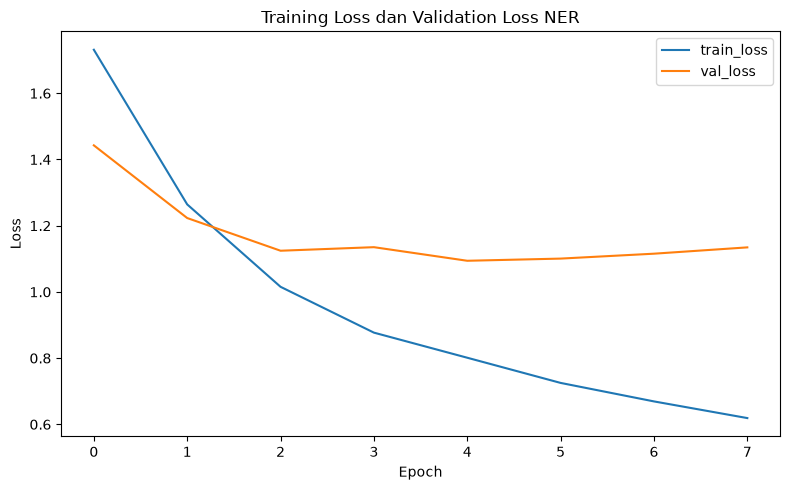

In [109]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss dan Validation Loss NER")
plt.legend()
plt.tight_layout()
plt.show()

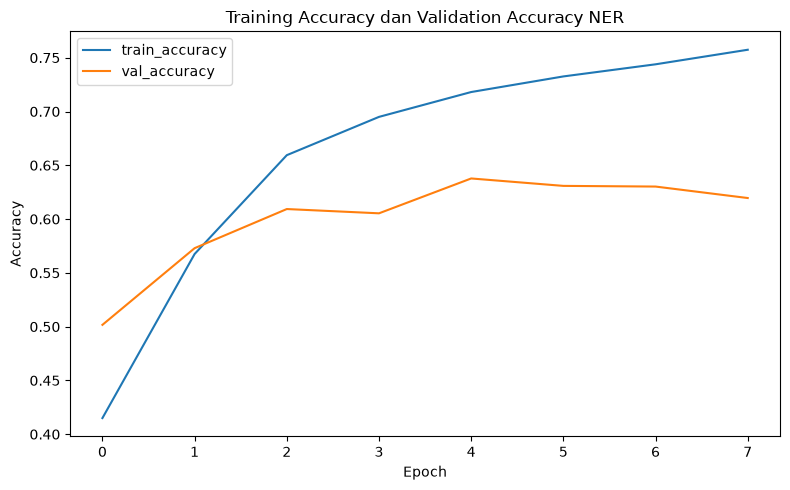

In [110]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy dan Validation Accuracy NER")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluation NER

In [111]:
y_test_pred_prob = model_ner.predict(X_test_ner)
y_test_pred_ner = np.argmax(y_test_pred_prob, axis=-1)

print("Shape y_test_pred_ner:", y_test_pred_ner.shape)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
Shape y_test_pred_ner: (211, 80)


In [112]:
true_tags_flat = []
pred_tags_flat = []
tokens_flat = []

for i in range(len(X_test_ner)):
    for j in range(MAX_LEN):
        token_id = X_test_ner[i][j]
        
        if token_id == word2idx["PAD"]:
            continue
        
        token = idx2word.get(int(token_id), "UNK")
        true_tag = idx2tag[int(y_test_ner[i][j])]
        pred_tag = idx2tag[int(y_test_pred_ner[i][j])]
        
        tokens_flat.append(token)
        true_tags_flat.append(true_tag)
        pred_tags_flat.append(pred_tag)

print("Jumlah token evaluasi:", len(true_tags_flat))

Jumlah token evaluasi: 4876


In [113]:
print(classification_report(
    true_tags_flat,
    pred_tags_flat,
    labels=tag_list,
    zero_division=0
))

              precision    recall  f1-score   support

     B-PLACE       0.78      0.39      0.52        80
     B-PRICE       0.50      0.04      0.07        26
   B-PRODUCT       0.68      0.42      0.52       311
 B-PROMOTION       1.00      0.02      0.04        50
     I-PLACE       0.75      0.79      0.77       531
     I-PRICE       0.54      0.42      0.47       119
   I-PRODUCT       0.76      0.80      0.78      1896
 I-PROMOTION       0.08      0.01      0.02       355
           O       0.56      0.73      0.63      1508

    accuracy                           0.67      4876
   macro avg       0.63      0.40      0.42      4876
weighted avg       0.64      0.67      0.64      4876



In [114]:
ner_report_dict = classification_report(
    true_tags_flat,
    pred_tags_flat,
    labels=tag_list,
    zero_division=0,
    output_dict=True
)

ner_report_df = pd.DataFrame(ner_report_dict).transpose()

ner_report_df.to_csv(
    "../models/Kelp4_ner_classification_report.csv"
)

ner_report_df

,precision,recall,f1-score,support
B-PLACE,0.775000,0.387500,0.516667,80.000000
B-PRICE,0.500000,0.038462,0.071429,26.000000
B-PRODUCT,0.675258,0.421222,0.518812,311.000000
B-PROMOTION,1.000000,0.020000,0.039216,50.000000
I-PLACE,0.750890,0.794727,0.772187,531.000000
I-PRICE,0.543478,0.420168,0.473934,119.000000
I-PRODUCT,0.756770,0.795886,0.775835,1896.000000
I-PROMOTION,0.076923,0.008451,0.015228,355.000000
O,0.560963,0.726127,0.632948,1508.000000
accuracy,0.665094,0.665094,0.665094,0.665094


In [115]:
ner_prediction_df = pd.DataFrame({
    "token": tokens_flat,
    "true_tag": true_tags_flat,
    "pred_tag": pred_tags_flat
})

ner_prediction_df["is_correct"] = (
    ner_prediction_df["true_tag"] == ner_prediction_df["pred_tag"]
)

ner_prediction_df.head(20)

,token,true_tag,pred_tag,is_correct
0,baksonya,B-PRODUCT,B-PRODUCT,True
1,enak,I-PRODUCT,I-PRODUCT,True
2,",",O,I-PRODUCT,False
3,tempatnya,B-PLACE,B-PLACE,True
4,ok,I-PLACE,I-PLACE,True
5,",",O,O,True
6,servicenya,O,O,True
7,juaraaa,O,O,True
8,😋,O,O,True
9,😋,O,I-PROMOTION,False


In [116]:
print("Distribusi benar/salah token:")
print(ner_prediction_df["is_correct"].value_counts())

ner_wrong_predictions = ner_prediction_df[
    ner_prediction_df["is_correct"] == False
].copy()

print("Jumlah token salah:", len(ner_wrong_predictions))

ner_wrong_predictions.head(20)

Distribusi benar/salah token:
is_correct
True     3243
False    1633
Name: count, dtype: int64
Jumlah token salah: 1633


,token,true_tag,pred_tag,is_correct
2,",",O,I-PRODUCT,False
9,😋,O,I-PROMOTION,False
10,😋,O,I-PROMOTION,False
11,😋,O,I-PROMOTION,False
12,😋,O,I-PROMOTION,False
13,😋,O,I-PROMOTION,False
18,",",I-PRODUCT,O,False
38,selain,B-PRODUCT,I-PLACE,False
39,itu,I-PRODUCT,I-PLACE,False
41,banyak,I-PRODUCT,I-PLACE,False


In [117]:
ner_prediction_df.to_csv(
    "../models/Kelp4_ner_token_predictions.csv",
    index=False
)

ner_wrong_predictions.to_csv(
    "../models/Kelp4_ner_wrong_token_predictions.csv",
    index=False
)

print("Prediksi token dan error NER berhasil disimpan.")

Prediksi token dan error NER berhasil disimpan.


In [118]:
cm = confusion_matrix(
    true_tags_flat,
    pred_tags_flat,
    labels=tag_list
)

ner_confusion_df = pd.DataFrame(
    cm,
    index=tag_list,
    columns=tag_list
)

ner_confusion_df

,B-PLACE,B-PRICE,B-PRODUCT,B-PROMOTION,I-PLACE,I-PRICE,I-PRODUCT,I-PROMOTION,O
B-PLACE,31,0,1,0,26,0,6,0,16
B-PRICE,1,1,0,0,2,14,4,2,2
B-PRODUCT,1,1,131,0,2,3,137,0,36
B-PROMOTION,0,0,0,1,4,1,1,1,42
I-PLACE,4,0,1,0,422,0,20,4,80
I-PRICE,0,0,6,0,14,50,14,1,34
I-PRODUCT,3,0,38,0,7,16,1509,1,322
I-PROMOTION,0,0,1,0,10,8,8,3,325
O,0,0,16,0,75,0,295,27,1095


In [119]:
ner_confusion_df.to_csv(
    "../models/Kelp4_ner_confusion_matrix.csv"
)

print("Confusion matrix NER berhasil disimpan.")

Confusion matrix NER berhasil disimpan.


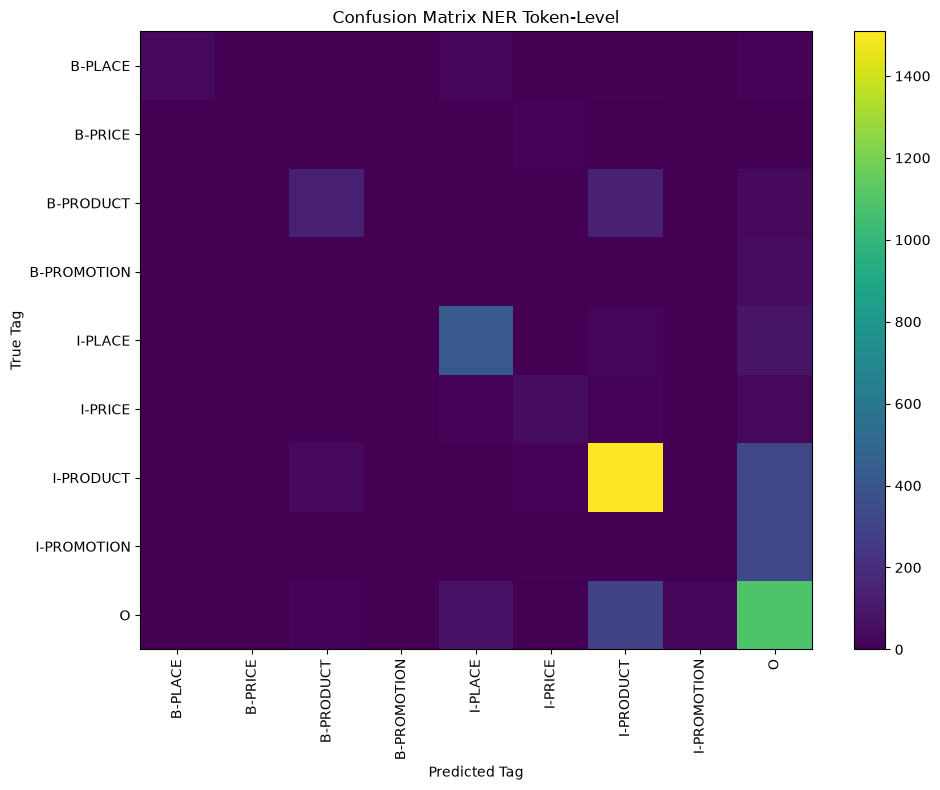

In [120]:
plt.figure(figsize=(10, 8))
plt.imshow(ner_confusion_df, aspect="auto")
plt.colorbar()
plt.xticks(range(len(tag_list)), tag_list, rotation=90)
plt.yticks(range(len(tag_list)), tag_list)
plt.xlabel("Predicted Tag")
plt.ylabel("True Tag")
plt.title("Confusion Matrix NER Token-Level")
plt.tight_layout()
plt.show()

In [121]:
boundary_error_rows = []

for _, row in ner_wrong_predictions.iterrows():
    true_tag = row["true_tag"]
    pred_tag = row["pred_tag"]
    
    if true_tag == "O" or pred_tag == "O":
        error_type = "Entity vs O Error"
    elif true_tag.split("-")[-1] != pred_tag.split("-")[-1]:
        error_type = "Label Error"
    elif true_tag.split("-")[0] != pred_tag.split("-")[0]:
        error_type = "Boundary Error"
    else:
        error_type = "Other Error"
    
    boundary_error_rows.append({
        "token": row["token"],
        "true_tag": true_tag,
        "pred_tag": pred_tag,
        "error_type": error_type
    })

ner_error_analysis_df = pd.DataFrame(boundary_error_rows)

ner_error_analysis_df.head(20)

,token,true_tag,pred_tag,error_type
0,",",O,I-PRODUCT,Entity vs O Error
1,😋,O,I-PROMOTION,Entity vs O Error
2,😋,O,I-PROMOTION,Entity vs O Error
3,😋,O,I-PROMOTION,Entity vs O Error
4,😋,O,I-PROMOTION,Entity vs O Error
5,😋,O,I-PROMOTION,Entity vs O Error
6,",",I-PRODUCT,O,Entity vs O Error
7,selain,B-PRODUCT,I-PLACE,Label Error
8,itu,I-PRODUCT,I-PLACE,Label Error
9,banyak,I-PRODUCT,I-PLACE,Label Error


In [122]:
ner_error_type_distribution = ner_error_analysis_df["error_type"].value_counts()

ner_error_type_distribution

error_type
Entity vs O Error    1270
Boundary Error        220
Label Error           143
Name: count, dtype: int64

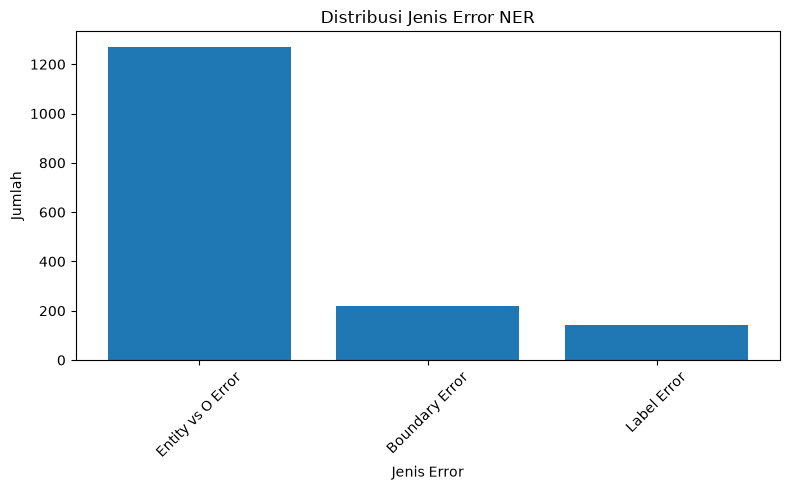

In [123]:
plt.figure(figsize=(8, 5))
plt.bar(
    ner_error_type_distribution.index,
    ner_error_type_distribution.values
)
plt.xticks(rotation=45)
plt.xlabel("Jenis Error")
plt.ylabel("Jumlah")
plt.title("Distribusi Jenis Error NER")
plt.tight_layout()
plt.show()

In [124]:
ner_error_analysis_df.to_csv(
    "../models/Kelp4_ner_error_analysis.csv",
    index=False
)

print("Error analysis NER berhasil disimpan.")

Error analysis NER berhasil disimpan.


In [125]:
from IPython.display import Markdown

Markdown("""
### Analisis Kesalahan NER

Berdasarkan hasil evaluasi token-level, model NER sudah mampu mengenali beberapa pola utama pada aspek PRODUCT, PLACE, dan tag O. Namun, model masih memiliki kelemahan pada tag minoritas seperti PRICE dan PROMOTION.

Pola kesalahan yang ditemukan:
1. Entity vs O Error: model sering memprediksi token entitas sebagai O atau sebaliknya.
2. Label Error: model salah menentukan jenis aspek, misalnya PRICE diprediksi sebagai PRODUCT atau PLACE.
3. Boundary Error: model salah membedakan awal entitas B- dan lanjutan entitas I-.
4. Label dengan jumlah data sedikit seperti B-PRICE, B-PROMOTION, dan I-PROMOTION memiliki F1-score rendah.

Penyebab utama:
1. Distribusi label NER tidak seimbang.
2. Token dengan label O dan PRODUCT lebih dominan.
3. Beberapa span memiliki lebih dari satu token sehingga boundary lebih sulit dipelajari.
4. Dataset price dan promotion lebih sedikit dibanding product dan place.
""")


### Analisis Kesalahan NER

Berdasarkan hasil evaluasi token-level, model NER sudah mampu mengenali beberapa pola utama pada aspek PRODUCT, PLACE, dan tag O. Namun, model masih memiliki kelemahan pada tag minoritas seperti PRICE dan PROMOTION.

Pola kesalahan yang ditemukan:
1. Entity vs O Error: model sering memprediksi token entitas sebagai O atau sebaliknya.
2. Label Error: model salah menentukan jenis aspek, misalnya PRICE diprediksi sebagai PRODUCT atau PLACE.
3. Boundary Error: model salah membedakan awal entitas B- dan lanjutan entitas I-.
4. Label dengan jumlah data sedikit seperti B-PRICE, B-PROMOTION, dan I-PROMOTION memiliki F1-score rendah.

Penyebab utama:
1. Distribusi label NER tidak seimbang.
2. Token dengan label O dan PRODUCT lebih dominan.
3. Beberapa span memiliki lebih dari satu token sehingga boundary lebih sulit dipelajari.
4. Dataset price dan promotion lebih sedikit dibanding product dan place.


In [126]:
model_ner.save("../models/Kelp4_best_ner_model.keras")

print("Model NER berhasil disimpan.")

Model NER berhasil disimpan.


In [127]:
joblib.dump(
    word2idx,
    "../models/Kelp4_ner_word2idx.pkl"
)

joblib.dump(
    idx2word,
    "../models/Kelp4_ner_idx2word.pkl"
)

joblib.dump(
    tag2idx,
    "../models/Kelp4_ner_tag2idx.pkl"
)

joblib.dump(
    idx2tag,
    "../models/Kelp4_ner_idx2tag.pkl"
)

ner_config = {
    "MAX_LEN": MAX_LEN,
    "VOCAB_SIZE": VOCAB_SIZE,
    "NUM_TAGS": NUM_TAGS
}

joblib.dump(
    ner_config,
    "../models/Kelp4_ner_config.pkl"
)

history_df.to_csv(
    "../models/Kelp4_ner_training_history.csv",
    index=False
)

print("Mapping, config, dan history NER berhasil disimpan.")

Mapping, config, dan history NER berhasil disimpan.


In [128]:
def simple_tokenize(text):
    tokens = re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)
    return tokens


def predict_ner_manual(text):
    tokens = simple_tokenize(text)
    
    token_ids = [
        word2idx.get(token, word2idx["UNK"])
        for token in tokens
    ]
    
    padded = pad_sequences(
        [token_ids],
        maxlen=MAX_LEN,
        padding="post",
        truncating="post",
        value=word2idx["PAD"]
    )
    
    pred_prob = model_ner.predict(padded, verbose=0)
    pred_ids = np.argmax(pred_prob, axis=-1)[0]
    
    used_len = min(len(tokens), MAX_LEN)
    
    result = pd.DataFrame({
        "token": tokens[:used_len],
        "predicted_tag": [
            idx2tag[int(tag_id)]
            for tag_id in pred_ids[:used_len]
        ]
    })
    
    return result

In [131]:
import re

In [132]:
sample_text = "Baksonya enak dan tempatnya luas tapi harganya mahal"

predict_ner_manual(sample_text)

,token,predicted_tag
0,Baksonya,B-PRODUCT
1,enak,I-PRODUCT
2,dan,I-PRODUCT
3,tempatnya,B-PLACE
4,luas,I-PLACE
5,tapi,I-PLACE
6,harganya,I-PLACE
7,mahal,I-PLACE
